In [1]:
# NGMeet implemented through the EM-EDX class

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from VCA import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from utils_noise import *

import pickle
import copy
import time
import humanfriendly

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import random
import humanfriendly
from torchmetrics.image import SpectralAngleMapper
import pacmap
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
import gc
import psutil
from multiprocessing import Pool
from scipy.optimize import nnls
from itertools import repeat
import matplotlib.patches as patches
from datetime import datetime

device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps


### Load unaligned data to denoise 

In [2]:
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned_20frames.pkl', 'rb') as file:
    tile = pickle.load(file)

tile.apply("crop", parameters = {"crop_idx": (slice(50,tile.EDX_dim[0]-50),slice(50,tile.EDX_dim[1]-50),slice(None,None,None))})
tile.apply("binning", parameters={"dim": (974,974,250)})
tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})

#h, w, b = tile.EDX_dim
tile.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None
5,MeanFilterEDX,kernel_size=3,"(974, 974)","(974, 974, 250)",None


### Load reference dataset

In [3]:
with open('../preprocessing_basic/results/preprocessed_edx/20260114_062341_tile_aligned_100frames_align2zero.pkl', 'rb') as file:
    tile_ref = pickle.load(file)

tile_ref.apply("crop", parameters = {"crop_idx": (slice(50,tile_ref.EDX_dim[0]-50),slice(50,tile_ref.EDX_dim[1]-50),slice(None,None,None))})
tile_ref.apply("binning", parameters={"dim": (int(tile_ref.EDX_dim[0]/2),int(tile_ref.EDX_dim[1]/2),250)})
tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})

#h, w, b = tile.EDX_dim
tile_ref.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_path=tmp/unaligned_hsi_100frames, al...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None
5,MeanFilterEDX,kernel_size=3,"(974, 974)","(974, 974, 250)",None


### Apply NGMeet

In [4]:
tile_NGMeet = tile.apply("NGMeet_matlab", parameters = {"sigma": 0.3, "nEM": 10, "nIter": 2},copy_instance=True)

print(tile_NGMeet.summary())

print(tile.summary())

       operation                                         parameters  \
0           crop  crop_idx=(slice(None, None, None), slice(None,...   
1        binning                              dim=(2048, 2048, 250)   
2   sofima_align  hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...   
3           crop  crop_idx=(slice(50, 1998, None), slice(50, 199...   
4        binning                                dim=(974, 974, 250)   
5  MeanFilterEDX                                      kernel_size=3   
6  NGMeet_matlab                         sigma=0.3, nEM=10, nIter=2   

     haadf size            EDX size notes  
0  (2048, 2048)  (2048, 2048, 4000)  None  
1  (2048, 2048)   (2048, 2048, 250)  None  
2  (2048, 2048)   (2048, 2048, 250)  None  
3  (1948, 1948)   (1948, 1948, 250)  None  
4    (974, 974)     (974, 974, 250)  None  
5    (974, 974)     (974, 974, 250)  None  
6    (974, 974)     (974, 974, 250)  None  
       operation                                         parameters  \
0       

### Check if it looks right (like in the OG notebook)

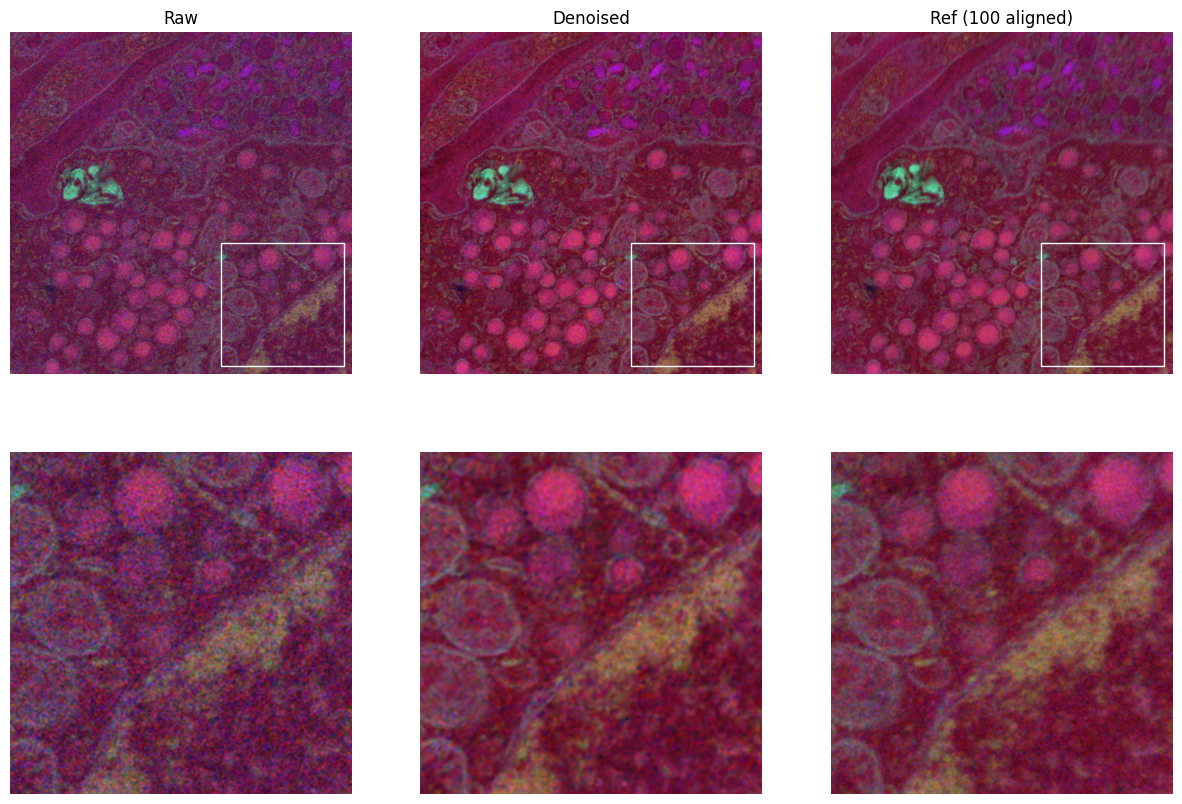

In [5]:
# compare
bands = [4,25,28]


#zoom = (slice(400,600),slice(150,350),slice(None))
zoom = (slice(600,950),slice(600,950),slice(None))


f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(tile.FalseColor(bands))
ax[0][0].set_title('Raw')
ax[0][1].imshow(tile_NGMeet.FalseColor(bands))
ax[0][1].set_title('Denoised')
ax[0][2].imshow(tile_ref.FalseColor(bands))
ax[0][2].set_title('Ref (100 aligned)')

ax[1][0].imshow(tile.FalseColor(bands)[zoom])
ax[1][1].imshow(tile_NGMeet.FalseColor(bands)[zoom])
ax[1][2].imshow(tile_ref.FalseColor(bands)[zoom])


# Extract rectangle from zoom slices
ys, xs, _ = zoom
y0 = ys.start or 0
y1 = ys.stop or metric_noisy.shape[0]
x0 = xs.start or 0
x1 = xs.stop or metric_noisy.shape[1]



ax[0][0].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))
ax[0][1].add_patch(
    patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))

ax[0][2].add_patch(
    patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))
for axx in ax.ravel():
    axx.axis('off')


plt.show()

### Save NGMeet denoised dataset into memory

In [14]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/preprocessed_edx/{timestamp}_tile_aligned20frames_NGMeet.pkl", "wb") as f:
    pickle.dump(tile_NGMeet, f)
